# Liu-Aligned Brain Figure — Scherf-style ventral surface maps

**Pipeline alignment:**
- Liu differential contrasts (cope 1=Face>Object, 2=House>Object, 3=Object>Scramble, -cope 13=Word>Face)
- Pre-registered MNI zstats (`zstat1_mni.nii.gz`, written by `13_register_zstats_mni.py`)
- WTA threshold z > 2.326 (one-tailed p<.01, matches sum-selectivity)
- VOTC mask: Harvard-Oxford labels (MNI 2mm)
- fsaverage5 surface

**Procedure:**
1. Load each subject's per-category MNI zstat from `cope{N}.feat/stats/zstat1_mni.nii.gz`.
2. Project continuous zstats to fsaverage5 surface (linear interp).
3. Average continuous zstats across controls.
4. WTA at threshold 2.326 → category label per vertex.
5. For patients: project individual zstats, WTA, mask to control-defined VOTC.

## Setup

In [1]:
import os, sys
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch
from collections import deque

from nilearn import surface, datasets
from nilearn.plotting import plot_surf_roi, plot_surf_stat_map
from nilearn.surface import load_surf_mesh
from nilearn import datasets as nl_datasets

sys.path.insert(0, '/user_data/csimmon2/git_repos/sym_pt')
from sym_pt_params import (processed_dir, skip_subs, get_sessions,
                           is_patient, get_sub_info, _load_csv)

# Liu contrasts (cope_num, negate). face=1; house=2; object=3; word=-13.
CATEGORIES = ['face', 'house', 'object', 'word']
LIU_CONTRASTS = {
    'face':   (1,  False),
    'house':  (2,  False),
    'object': (3,  False),
    'word':   (13, True),
}

GROUP_ZTHRESH      = 2.326
INDIVIDUAL_ZTHRESH = 2.326
VOL_TO_SURF_RADIUS = 3.0

EXTRA_SKIP = {'sub-017', 'control083', 'control085'}
PRE_SURGERY_SESSIONS = {
    'sub-021': {'01'}, 'sub-045': {'01'}, 'sub-047': {'01'}, 'sub-049': {'01'},
    'sub-070': {'01'}, 'sub-073': {'01'}, 'sub-081': {'01'}, 'sub-086': {'01'},
    'sub-108': {'02'},
}

OUT_DIR = os.path.join(processed_dir, 'group_results', 'figures', 'brain_figure_liu')
os.makedirs(OUT_DIR, exist_ok=True)

CAT_COLORS = {'face': '#E74C3C', 'house': '#2ECC71',
              'object': '#3498DB', 'word': '#FFD700'}
cat_cmap = ListedColormap(['#808080',
                            CAT_COLORS['face'], CAT_COLORS['house'],
                            CAT_COLORS['object'], CAT_COLORS['word']])

fsaverage = datasets.fetch_surf_fsaverage(mesh='fsaverage5')
N_VERTICES = 10242

plt.rcParams['font.sans-serif'] = ['Arial', 'Liberation Sans', 'DejaVu Sans']
plt.rcParams['font.family'] = 'sans-serif'

print(f'Output: {OUT_DIR}')
print(f'WTA threshold: z > {GROUP_ZTHRESH}')

Output: /user_data/csimmon2/sym_pt/group_results/figures/brain_figure_liu
WTA threshold: z > 2.326


## Subject Loader

In [2]:
def load_subjects():
    df = _load_csv()
    subjects = {}
    for sc in sorted(df['sub_clean'].unique()):
        if sc in skip_subs:
            continue
        sid = f'sub-{sc}'
        sessions = get_sessions(sc)
        base = os.path.join(processed_dir, sid)
        if not sessions or not os.path.exists(base):
            continue
        info = get_sub_info(sc, sessions[0])
        pt = is_patient(sc)
        intact = info.get('intact_hemi', '')
        code_str = f"{info.get('group', '')}{sc}"
        if code_str in EXTRA_SKIP or sid in EXTRA_SKIP:
            continue

        actual_first_ses = f'{sessions[0]:02d}'
        post_sessions = []
        for s in sessions:
            ses_str = f'{s:02d}'
            if ses_str in PRE_SURGERY_SESSIONS.get(sid, set()):
                continue
            post_sessions.append(ses_str)
        if not post_sessions:
            continue

        subjects[sid] = {
            'code': code_str,
            'sessions': post_sessions,
            'actual_first_ses': actual_first_ses,
            'hemi': ('l' if intact == 'left' else 'r') if pt else None,
            'group': info.get('group', 'unknown'),
            'patient_status': info.get('group', 'unknown'),
            'intact_hemi': intact,
            'surgery_side': ('right' if intact == 'left' else 'left') if pt else 'na',
        }
    return subjects


subjects = load_subjects()
ctrl_sids = sorted([s for s, i in subjects.items() if i['patient_status'] == 'control'])
otc_sids  = sorted([s for s, i in subjects.items() if i['patient_status'] == 'OTC'])
print(f'Controls: {len(ctrl_sids)}, OTC: {len(otc_sids)}')

Controls: 38, OTC: 25


## Helpers — load MNI zstats, project to surface

In [3]:
def get_mni_zstat_path(sub_id, session, cope_num):
    feat_dir = os.path.join(processed_dir, sub_id, f'ses-{session}',
                            'derivatives', 'fsl', 'loc', 'HighLevel.gfeat')
    return os.path.join(feat_dir, f'cope{cope_num}.feat', 'stats', 'zstat1_mni.nii.gz')


def project_zstats_to_surface(sub_id, session, hemi_nilearn):
    """Project all 4 Liu-contrast zstats to fsaverage5 (negate word)."""
    pial = fsaverage[f'pial_{hemi_nilearn}']
    surf_z = {}
    for cat, (cope_num, negate) in LIU_CONTRASTS.items():
        path = get_mni_zstat_path(sub_id, session, cope_num)
        if not os.path.exists(path):
            print(f'    MISSING: {path}')
            return None
        img = nib.load(path)
        if negate:
            data = -img.get_fdata()
            img = nib.Nifti1Image(data, img.affine, img.header)
        surf_z[cat] = surface.vol_to_surf(
            img, pial,
            interpolation='linear',
            radius=VOL_TO_SURF_RADIUS,
            kind='line',
        )
    return surf_z


def surface_wta(surf_zstats, threshold):
    zmat = np.column_stack([surf_zstats[cat] for cat in CATEGORIES])
    max_z = np.max(zmat, axis=1)
    winner = np.argmax(zmat, axis=1) + 1
    return np.where(max_z >= threshold, winner, 0).astype(int)


print('Helpers defined.')

Helpers defined.


## VOTC mask (Harvard-Oxford, MNI 2mm)

In [4]:
ho_atlas = nl_datasets.fetch_atlas_harvard_oxford('cort-maxprob-thr25-2mm')
ho_img = ho_atlas.maps if isinstance(ho_atlas.maps, nib.Nifti1Image) else nib.load(ho_atlas.maps)
ho_data = ho_img.get_fdata()
ho_labels = ho_atlas.labels

votc_label_names = [
    'Temporal Fusiform Cortex, anterior division',
    'Temporal Fusiform Cortex, posterior division',
    'Temporal Occipital Fusiform Cortex',
    'Parahippocampal Gyrus, anterior division',
    'Parahippocampal Gyrus, posterior division',
    'Lingual Gyrus',
    'Lateral Occipital Cortex, superior division',
    'Lateral Occipital Cortex, inferior division',
]

votc_mask_data = np.zeros(ho_data.shape, dtype=bool)
for name in votc_label_names:
    matches = [i for i, l in enumerate(ho_labels) if name in l]
    if matches:
        votc_mask_data |= (ho_data == matches[0])

votc_mask_img = nib.Nifti1Image(votc_mask_data.astype(np.float32), ho_img.affine)

votc_mask_surf_lh = surface.vol_to_surf(
    votc_mask_img, fsaverage['pial_left'],
    interpolation='nearest', radius=6.0, kind='ball') > 0
votc_mask_surf_rh = surface.vol_to_surf(
    votc_mask_img, fsaverage['pial_right'],
    interpolation='nearest', radius=6.0, kind='ball') > 0

print(f'LH VOTC: {votc_mask_surf_lh.sum():,} vertices')
print(f'RH VOTC: {votc_mask_surf_rh.sum():,} vertices')

coords_lh, faces_lh = load_surf_mesh(fsaverage['infl_left'])
coords_rh, faces_rh = load_surf_mesh(fsaverage['infl_right'])

LH VOTC: 2,273 vertices
RH VOTC: 2,169 vertices


## Cluster cleaner

In [5]:
def remove_small_clusters(roi_map, mesh_faces, min_size=30):
    n_verts = len(roi_map)
    adj = [set() for _ in range(n_verts)]
    for f in mesh_faces:
        adj[f[0]].update([f[1], f[2]])
        adj[f[1]].update([f[0], f[2]])
        adj[f[2]].update([f[0], f[1]])

    cleaned = roi_map.copy()
    visited = np.zeros(n_verts, dtype=bool)
    for v in range(n_verts):
        if visited[v] or roi_map[v] == 0:
            continue
        cat_val = roi_map[v]
        cluster = []
        queue = deque([v])
        visited[v] = True
        while queue:
            curr = queue.popleft()
            cluster.append(curr)
            for nb in adj[curr]:
                if not visited[nb] and roi_map[nb] == cat_val:
                    visited[nb] = True
                    queue.append(nb)
        if len(cluster) < min_size:
            for idx in cluster:
                cleaned[idx] = 0
    return cleaned

print('Cluster cleaner defined.')

Cluster cleaner defined.


## Group control maps — average continuous zstats, then WTA

In [6]:
avg_z_store = {}

for hemi_nl in ['left', 'right']:
    print(f'\n── {hemi_nl.upper()} ──')
    sum_z = None
    n_loaded = 0
    for sid in ctrl_sids:
        info = subjects[sid]
        first_ses = info['sessions'][0]
        sz = project_zstats_to_surface(sid, first_ses, hemi_nl)
        if sz is None:
            continue
        if sum_z is None:
            sum_z = {cat: sz[cat].copy() for cat in CATEGORIES}
        else:
            for cat in CATEGORIES:
                sum_z[cat] += sz[cat]
        n_loaded += 1
        print(f'  {sid} ({n_loaded})', end='\r')

    if n_loaded == 0:
        print(f'  No controls loaded for {hemi_nl}!')
        continue
    avg_z_store[hemi_nl] = {cat: sum_z[cat] / n_loaded for cat in CATEGORIES}
    print(f'\n  {n_loaded} controls averaged')

avg_z_lh = avg_z_store['left']
avg_z_rh = avg_z_store['right']

ctrl_roi_lh = surface_wta(avg_z_lh, GROUP_ZTHRESH)
ctrl_roi_rh = surface_wta(avg_z_rh, GROUP_ZTHRESH)
ctrl_roi_lh[~votc_mask_surf_lh] = 0
ctrl_roi_rh[~votc_mask_surf_rh] = 0

print(f'\nControls LH (z>{GROUP_ZTHRESH}, VOTC):')
for c, cat in enumerate(CATEGORIES):
    print(f'  {cat}: {np.sum(ctrl_roi_lh == c+1):,} vertices')
print(f'\nControls RH (z>{GROUP_ZTHRESH}, VOTC):')
for c, cat in enumerate(CATEGORIES):
    print(f'  {cat}: {np.sum(ctrl_roi_rh == c+1):,} vertices')


── LEFT ──
  sub-097 (38)
  38 controls averaged

── RIGHT ──
  sub-097 (38)
  38 controls averaged

Controls LH (z>2.326, VOTC):
  face: 10 vertices
  house: 41 vertices
  object: 560 vertices
  word: 0 vertices

Controls RH (z>2.326, VOTC):
  face: 10 vertices
  house: 81 vertices
  object: 392 vertices
  word: 0 vertices


## Plot group control maps

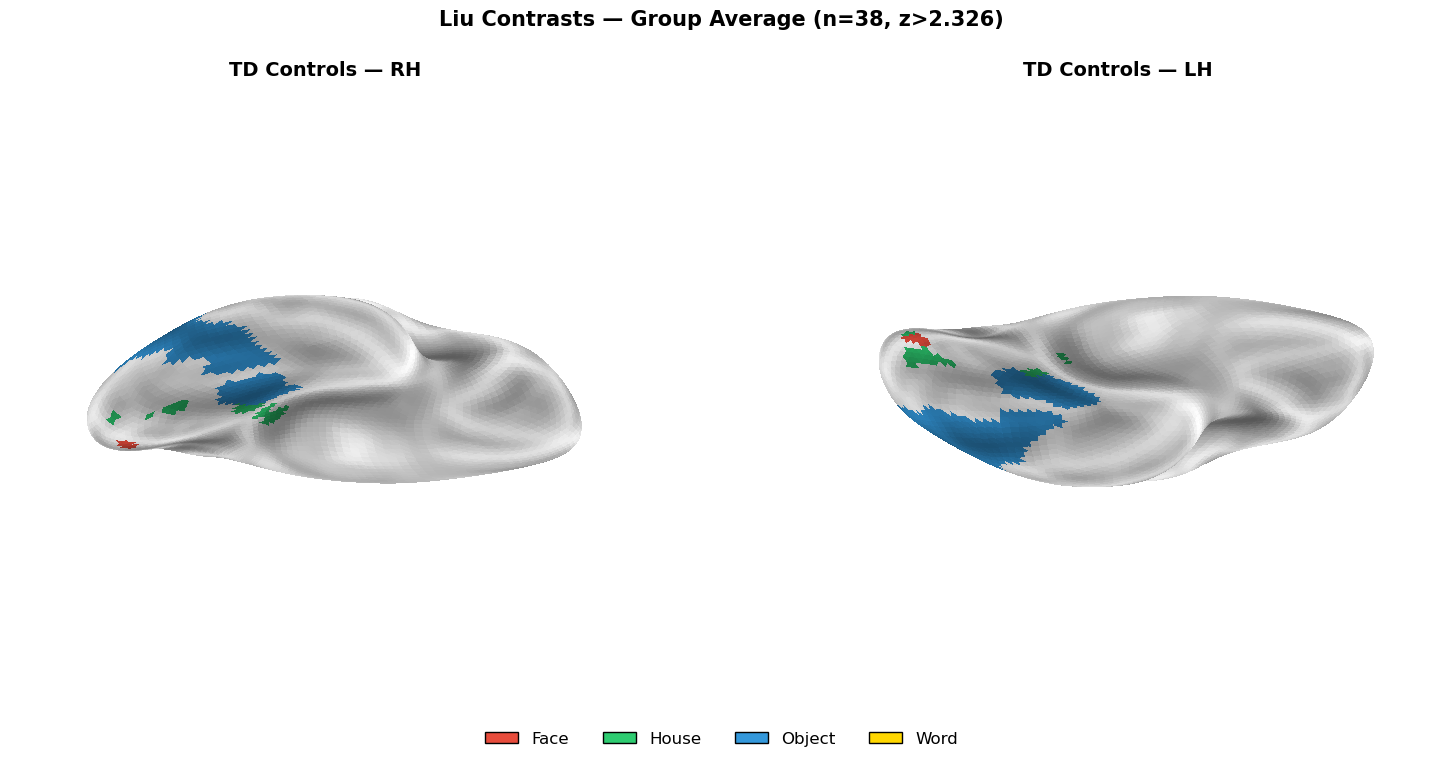

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 8),
                          subplot_kw={'projection': '3d'})
plot_surf_roi(fsaverage['infl_right'], roi_map=ctrl_roi_rh,
              hemi='right', view='ventral',
              cmap=cat_cmap, vmin=0, vmax=4,
              bg_map=fsaverage['sulc_right'],
              bg_on_data=True, darkness=0.7, axes=axes[0])
axes[0].set_title('TD Controls — RH', fontsize=14, fontweight='bold')

plot_surf_roi(fsaverage['infl_left'], roi_map=ctrl_roi_lh,
              hemi='left', view='ventral',
              cmap=cat_cmap, vmin=0, vmax=4,
              bg_map=fsaverage['sulc_left'],
              bg_on_data=True, darkness=0.7, axes=axes[1])
axes[1].set_title('TD Controls — LH', fontsize=14, fontweight='bold')

legend_patches = [Patch(facecolor=CAT_COLORS[c], edgecolor='k', label=c.capitalize())
                  for c in CATEGORIES]
fig.legend(handles=legend_patches, loc='lower center', ncol=4,
           fontsize=12, frameon=False, bbox_to_anchor=(0.5, 0.02))

plt.suptitle(f'Liu Contrasts — Group Average (n={len(ctrl_sids)}, z>{GROUP_ZTHRESH})',
             fontsize=15, fontweight='bold', y=0.96)
plt.tight_layout(rect=[0, 0.06, 1, 0.93])
plt.savefig(os.path.join(OUT_DIR, 'group_controls_liu.png'),
            dpi=300, bbox_inches='tight', transparent=True)
plt.show()

## Individual patients — plot intact hemisphere

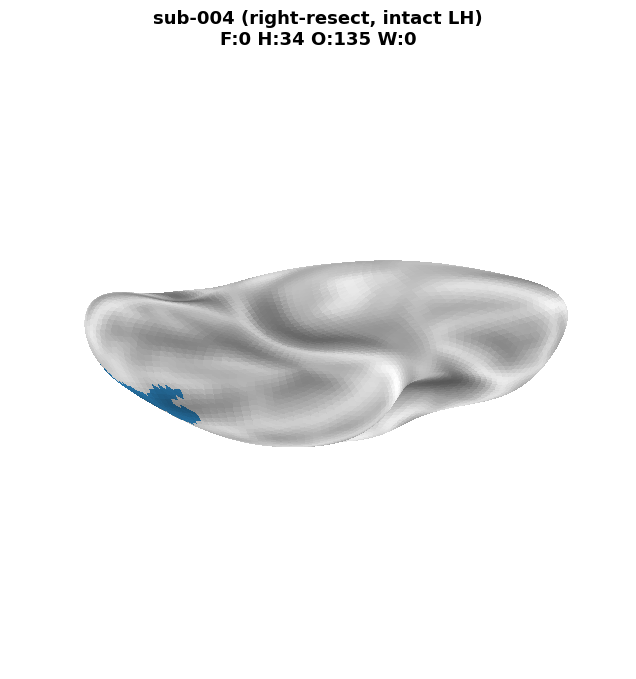

  Saved: /user_data/csimmon2/sym_pt/group_results/figures/brain_figure_liu/sub-004_ses-01_liu.png


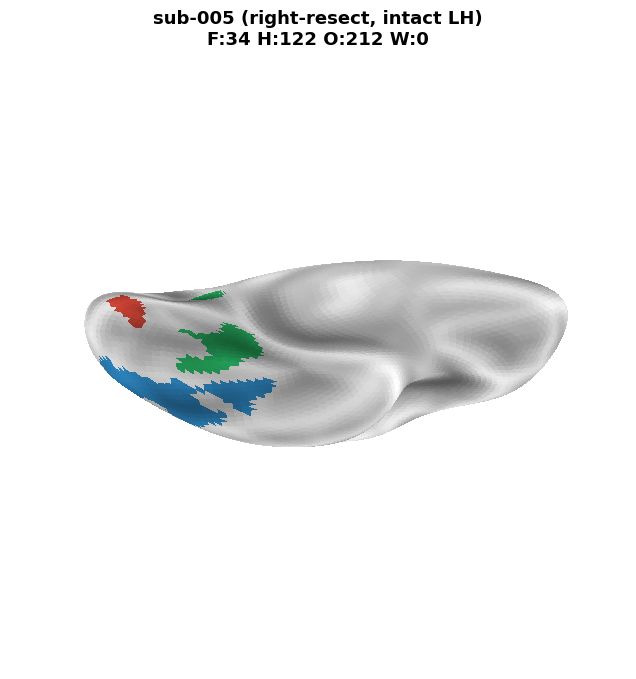

  Saved: /user_data/csimmon2/sym_pt/group_results/figures/brain_figure_liu/sub-005_ses-01_liu.png


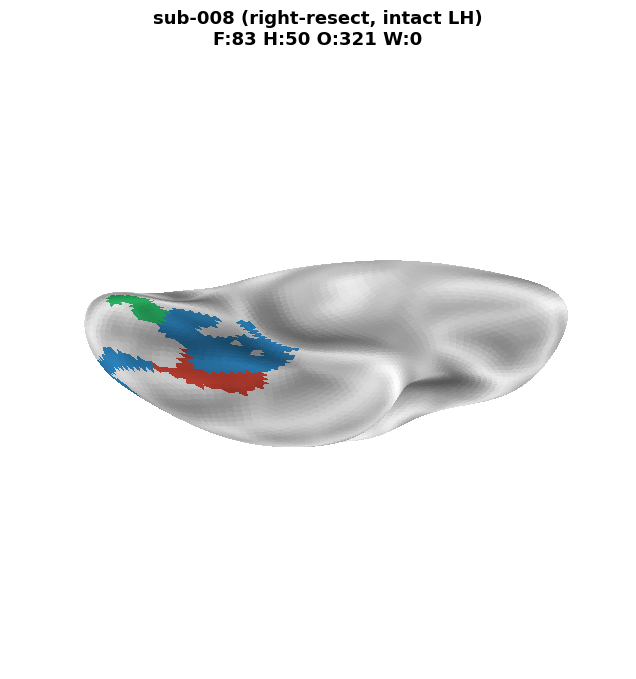

  Saved: /user_data/csimmon2/sym_pt/group_results/figures/brain_figure_liu/sub-008_ses-01_liu.png


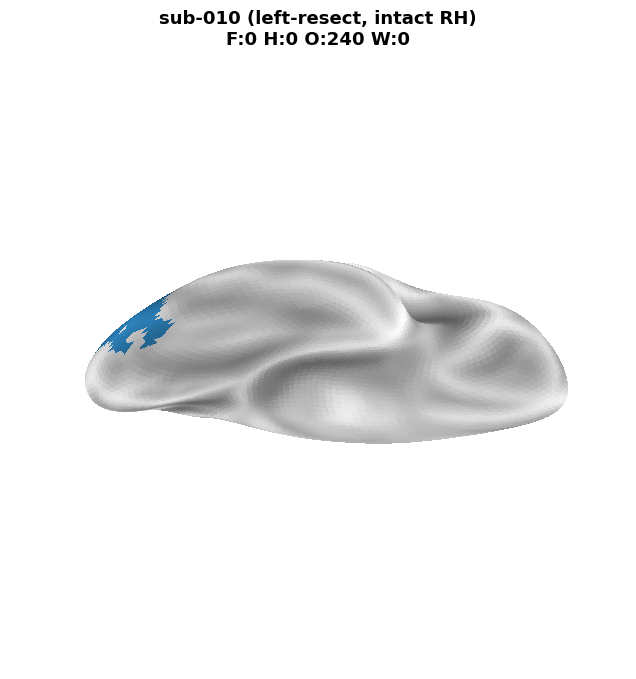

  Saved: /user_data/csimmon2/sym_pt/group_results/figures/brain_figure_liu/sub-010_ses-02_liu.png


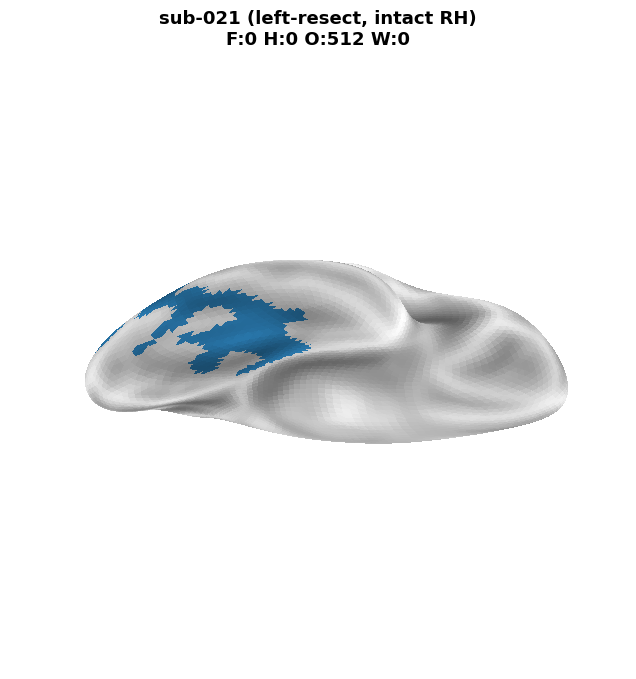

  Saved: /user_data/csimmon2/sym_pt/group_results/figures/brain_figure_liu/sub-021_ses-02_liu.png


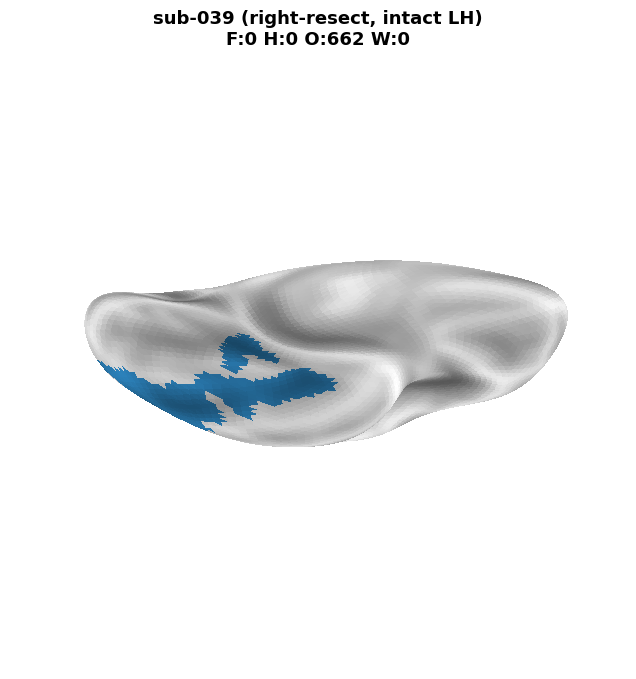

  Saved: /user_data/csimmon2/sym_pt/group_results/figures/brain_figure_liu/sub-039_ses-01_liu.png


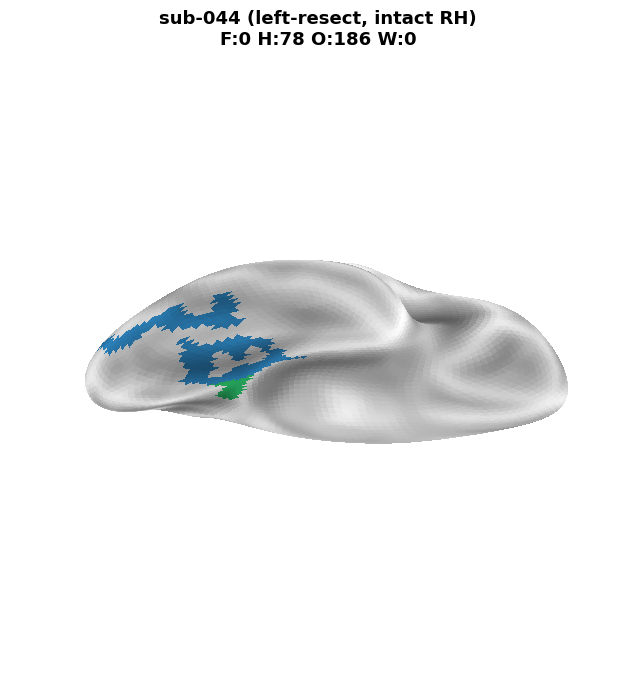

  Saved: /user_data/csimmon2/sym_pt/group_results/figures/brain_figure_liu/sub-044_ses-01_liu.png


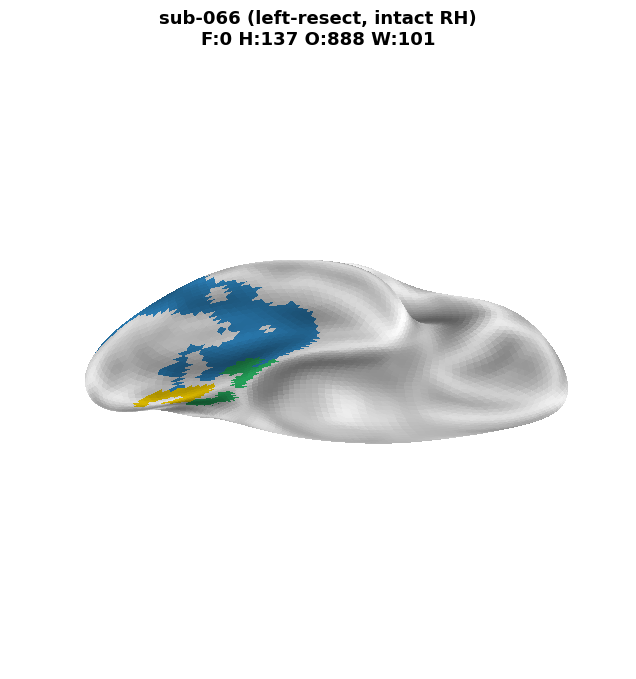

  Saved: /user_data/csimmon2/sym_pt/group_results/figures/brain_figure_liu/sub-066_ses-01_liu.png


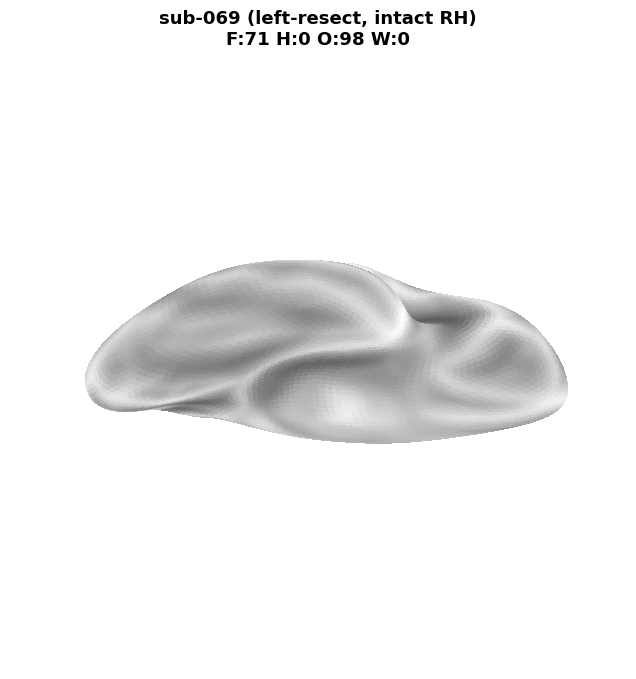

  Saved: /user_data/csimmon2/sym_pt/group_results/figures/brain_figure_liu/sub-069_ses-01_liu.png


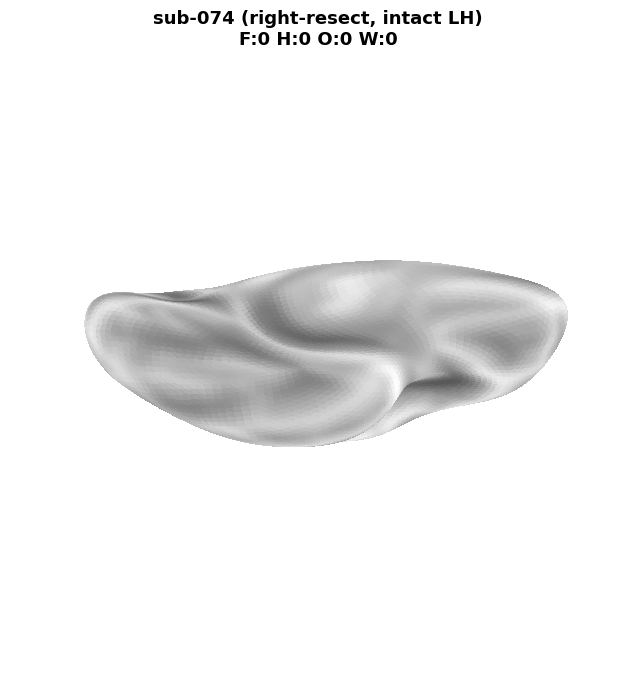

  Saved: /user_data/csimmon2/sym_pt/group_results/figures/brain_figure_liu/sub-074_ses-01_liu.png


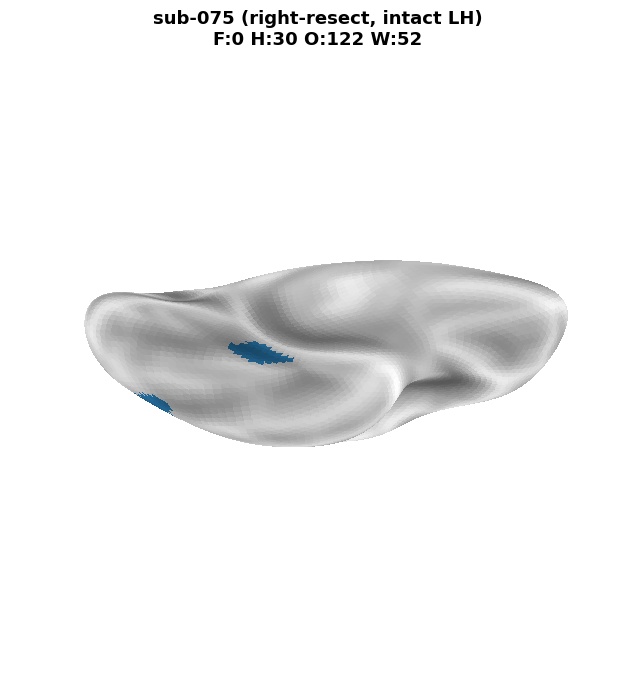

  Saved: /user_data/csimmon2/sym_pt/group_results/figures/brain_figure_liu/sub-075_ses-01_liu.png


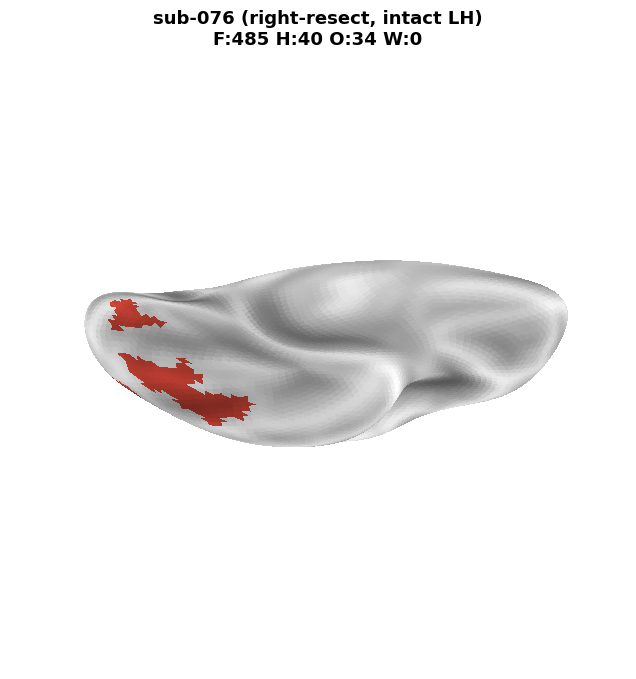

  Saved: /user_data/csimmon2/sym_pt/group_results/figures/brain_figure_liu/sub-076_ses-01_liu.png


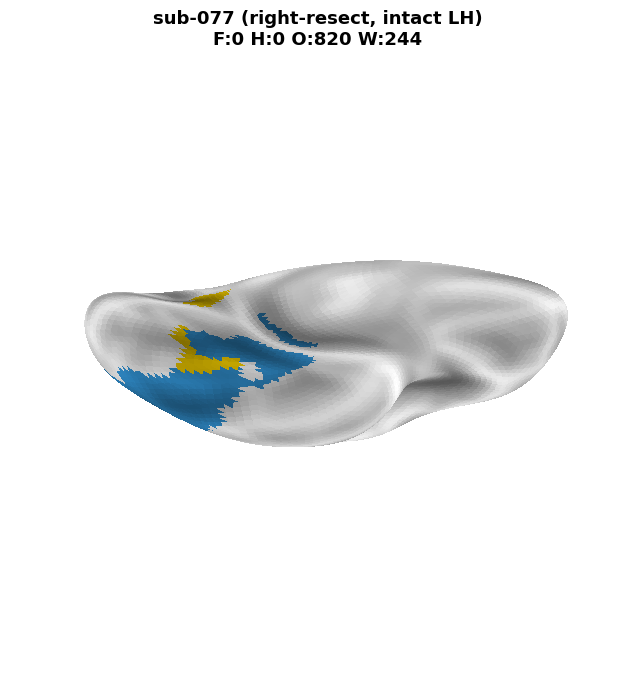

  Saved: /user_data/csimmon2/sym_pt/group_results/figures/brain_figure_liu/sub-077_ses-01_liu.png


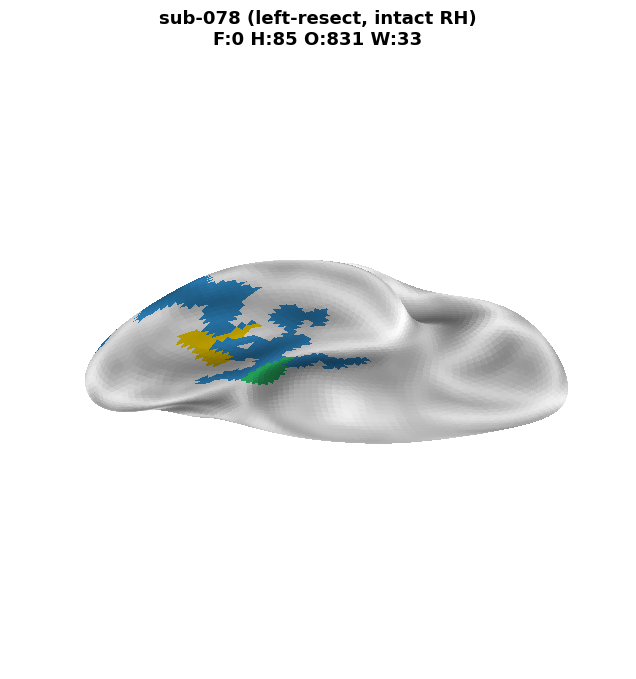

  Saved: /user_data/csimmon2/sym_pt/group_results/figures/brain_figure_liu/sub-078_ses-01_liu.png


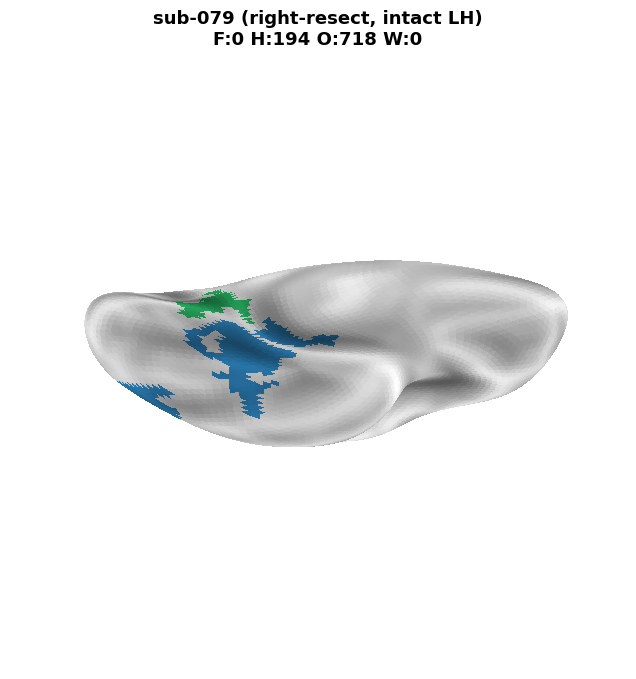

  Saved: /user_data/csimmon2/sym_pt/group_results/figures/brain_figure_liu/sub-079_ses-01_liu.png


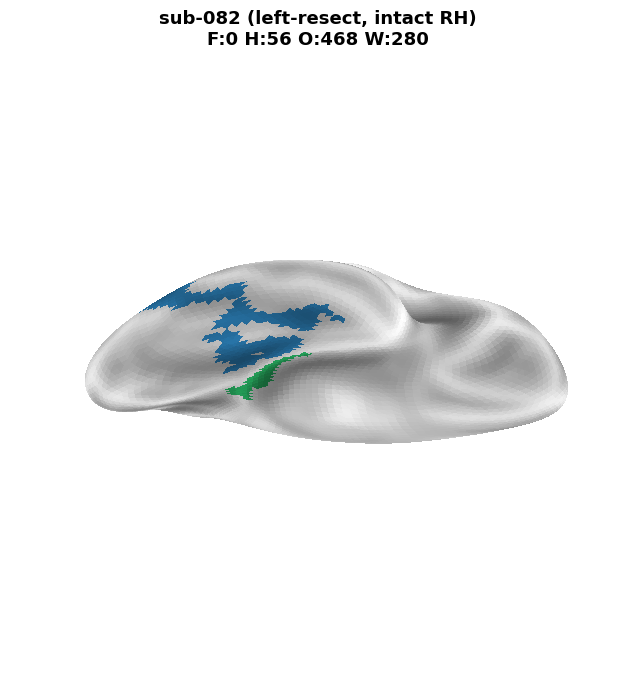

  Saved: /user_data/csimmon2/sym_pt/group_results/figures/brain_figure_liu/sub-082_ses-01_liu.png


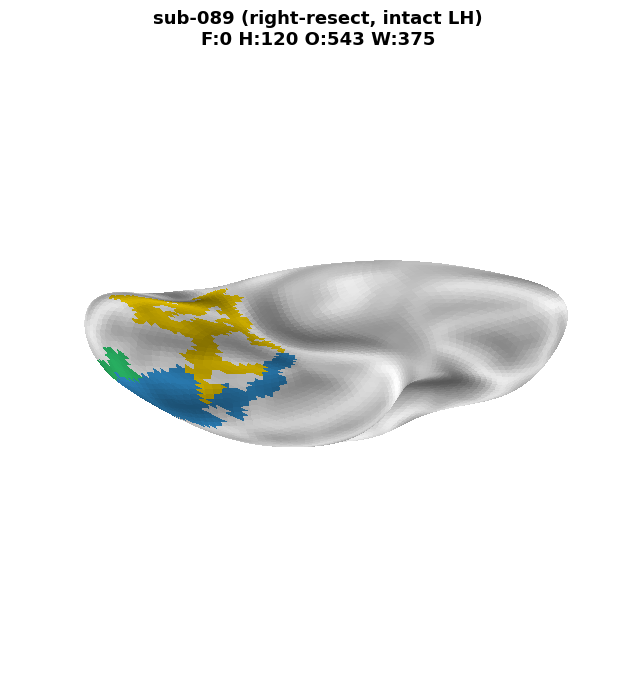

  Saved: /user_data/csimmon2/sym_pt/group_results/figures/brain_figure_liu/sub-089_ses-01_liu.png


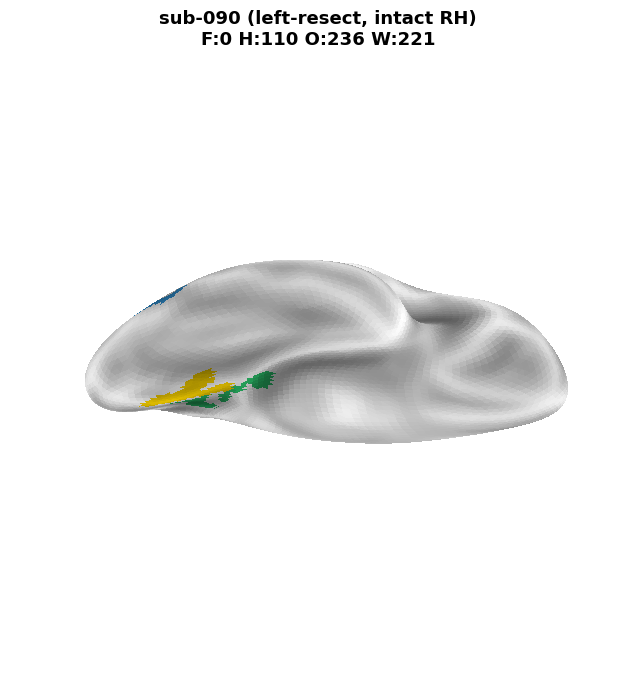

  Saved: /user_data/csimmon2/sym_pt/group_results/figures/brain_figure_liu/sub-090_ses-01_liu.png


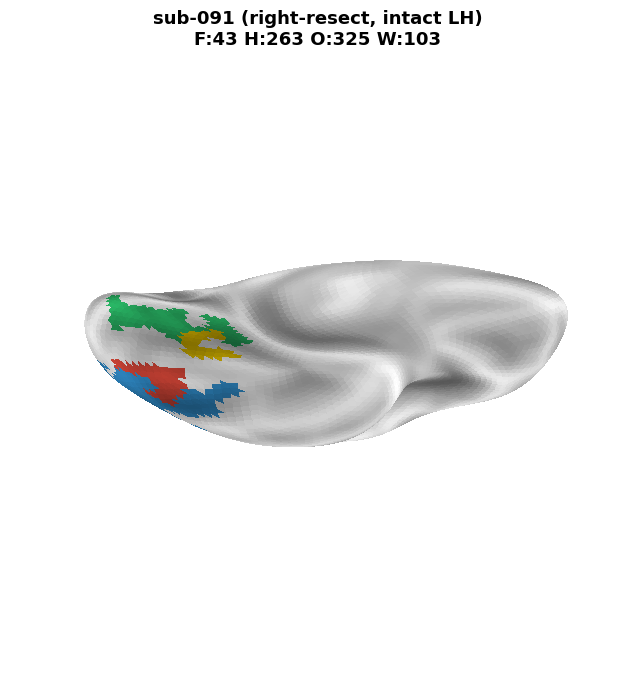

  Saved: /user_data/csimmon2/sym_pt/group_results/figures/brain_figure_liu/sub-091_ses-01_liu.png


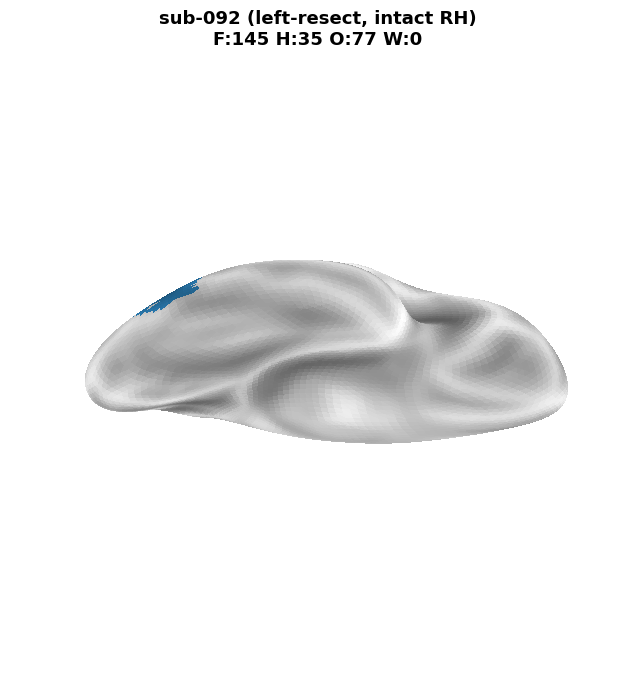

  Saved: /user_data/csimmon2/sym_pt/group_results/figures/brain_figure_liu/sub-092_ses-01_liu.png
    MISSING: /user_data/csimmon2/sym_pt/sub-098/ses-01/derivatives/fsl/loc/HighLevel.gfeat/cope1.feat/stats/zstat1_mni.nii.gz
sub-098: missing zstats


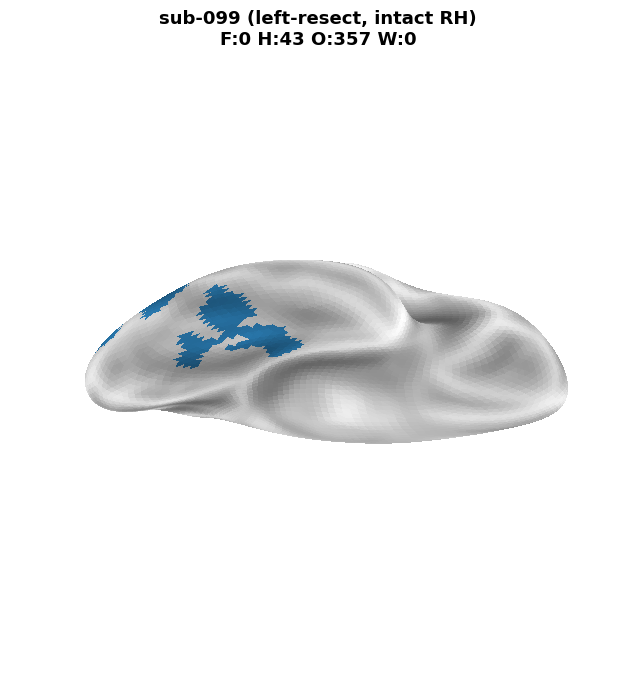

  Saved: /user_data/csimmon2/sym_pt/group_results/figures/brain_figure_liu/sub-099_ses-01_liu.png
    MISSING: /user_data/csimmon2/sym_pt/sub-101/ses-01/derivatives/fsl/loc/HighLevel.gfeat/cope1.feat/stats/zstat1_mni.nii.gz
sub-101: missing zstats


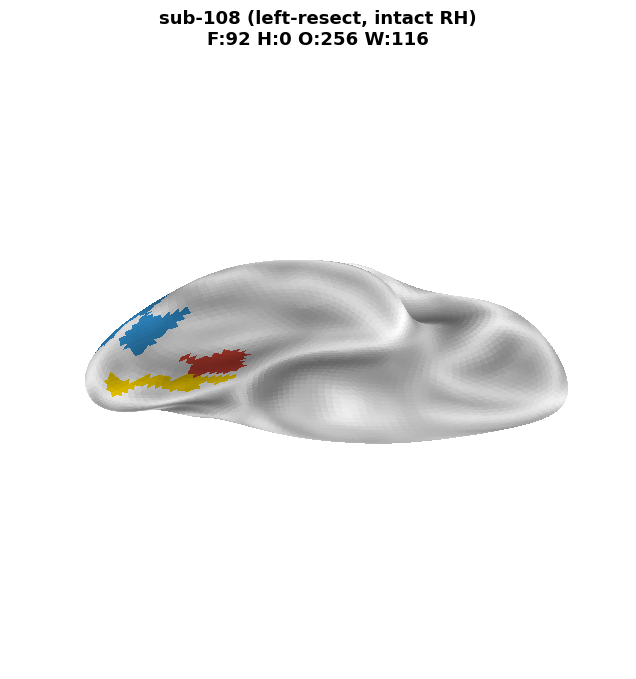

  Saved: /user_data/csimmon2/sym_pt/group_results/figures/brain_figure_liu/sub-108_ses-01_liu.png
    MISSING: /user_data/csimmon2/sym_pt/sub-109/ses-01/derivatives/fsl/loc/HighLevel.gfeat/cope1.feat/stats/zstat1_mni.nii.gz
sub-109: missing zstats


In [8]:
# Edit list to plot specific patients. Default: all OTC.
EXAMPLE_PATIENTS = otc_sids

for sid in EXAMPLE_PATIENTS:
    info = subjects[sid]
    intact = info['hemi']
    if intact is None:
        continue
    intact_nl = 'left' if intact == 'l' else 'right'
    intact_label = 'LH' if intact == 'l' else 'RH'
    surgery = info['surgery_side']
    first_ses = info['sessions'][0]

    surf_z = project_zstats_to_surface(sid, first_ses, intact_nl)
    if surf_z is None:
        print(f'{sid}: missing zstats')
        continue

    pat_roi = surface_wta(surf_z, INDIVIDUAL_ZTHRESH)
    votc = votc_mask_surf_lh if intact == 'l' else votc_mask_surf_rh
    pat_roi[~votc] = 0
    faces = faces_lh if intact == 'l' else faces_rh
    pat_roi = remove_small_clusters(pat_roi, faces, min_size=30)

    counts = {cat: int(np.sum(pat_roi == c+1)) for c, cat in enumerate(CATEGORIES)}

    fig, ax = plt.subplots(1, 1, figsize=(8, 8),
                            subplot_kw={'projection': '3d'})
    plot_surf_roi(fsaverage[f'infl_{intact_nl}'], roi_map=pat_roi,
                  hemi=intact_nl, view='ventral',
                  cmap=cat_cmap, vmin=0, vmax=4,
                  bg_map=fsaverage[f'sulc_{intact_nl}'],
                  bg_on_data=True, darkness=0.7, axes=ax)
    ax.set_title(f'{sid} ({surgery}-resect, intact {intact_label})\n'
                 f'F:{counts["face"]} H:{counts["house"]} '
                 f'O:{counts["object"]} W:{counts["word"]}',
                 fontsize=13, fontweight='bold')

    out = os.path.join(OUT_DIR, f'{sid}_ses-{first_ses}_liu.png')
    plt.savefig(out, dpi=300, bbox_inches='tight', transparent=True)
    plt.show()
    print(f'  Saved: {out}')

## Composite figure — controls + 1 example patient

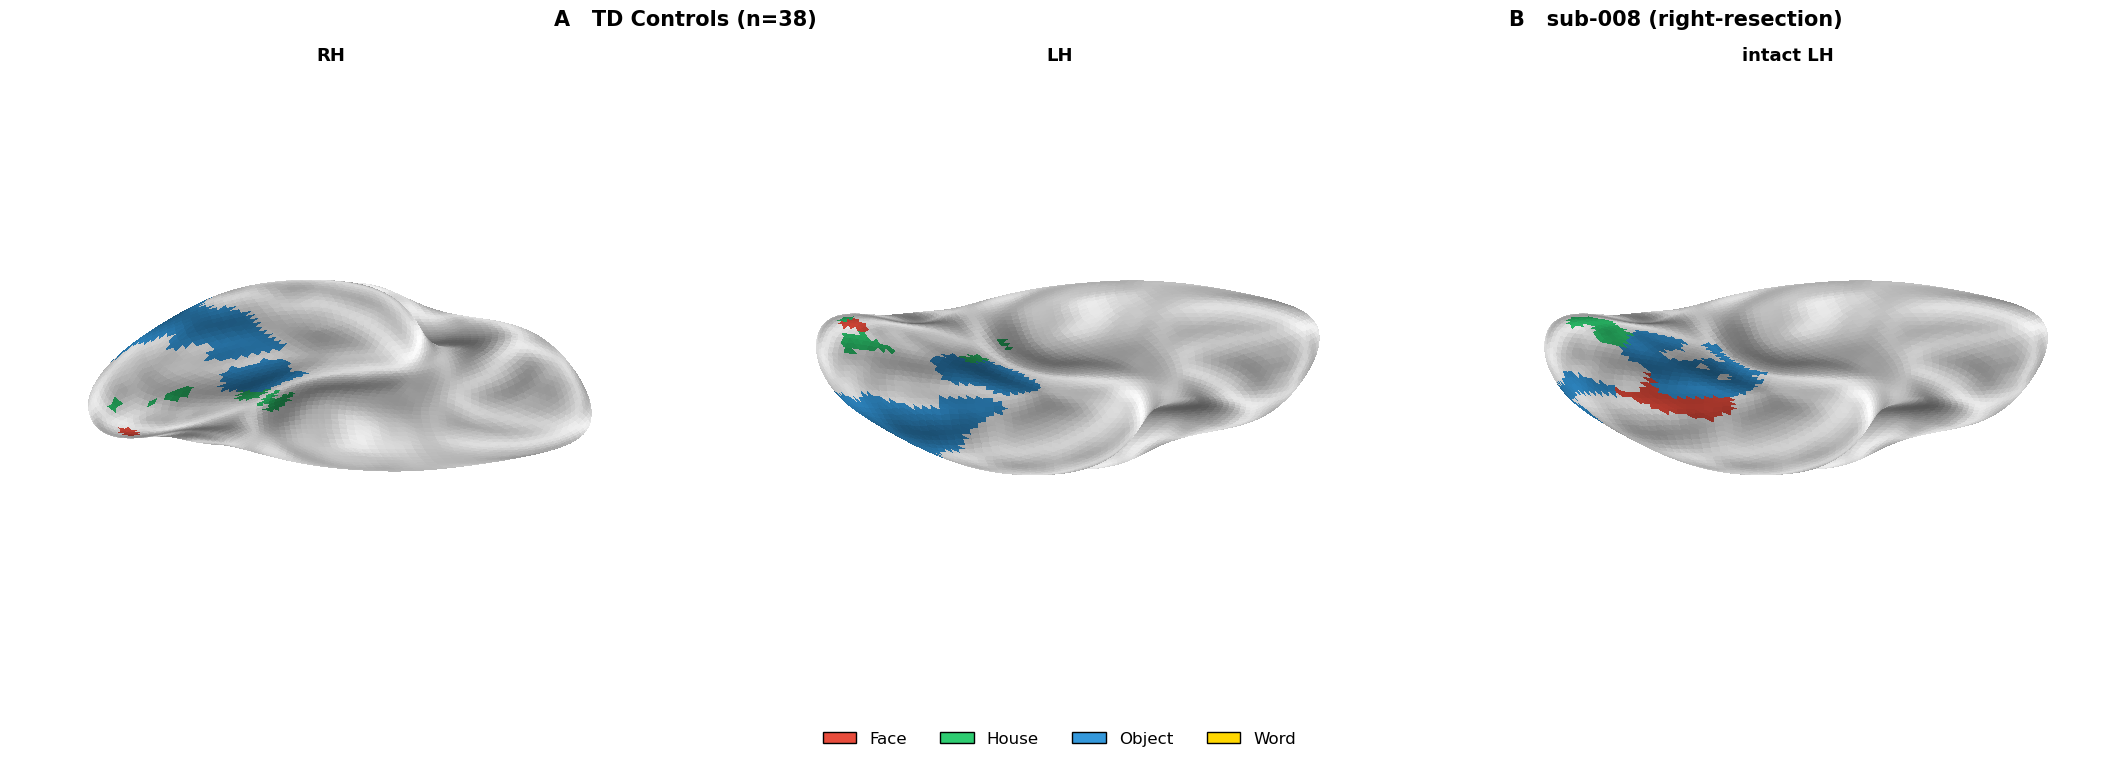

Saved: /user_data/csimmon2/sym_pt/group_results/figures/brain_figure_liu/composite_liu_sub-008.png


In [9]:
EXAMPLE_PATIENT = 'sub-008'   # edit to taste

if EXAMPLE_PATIENT in subjects:
    info = subjects[EXAMPLE_PATIENT]
    intact = info['hemi']
    intact_nl = 'left' if intact == 'l' else 'right'
    surgery = info['surgery_side']
    first_ses = info['sessions'][0]

    surf_z = project_zstats_to_surface(EXAMPLE_PATIENT, first_ses, intact_nl)
    pat_roi = surface_wta(surf_z, INDIVIDUAL_ZTHRESH)
    votc = votc_mask_surf_lh if intact == 'l' else votc_mask_surf_rh
    pat_roi[~votc] = 0
    faces = faces_lh if intact == 'l' else faces_rh
    pat_roi = remove_small_clusters(pat_roi, faces, min_size=30)

    fig = plt.figure(figsize=(22, 8))
    ax1 = fig.add_subplot(1, 3, 1, projection='3d')
    plot_surf_roi(fsaverage['infl_right'], roi_map=ctrl_roi_rh,
                  hemi='right', view='ventral',
                  cmap=cat_cmap, vmin=0, vmax=4,
                  bg_map=fsaverage['sulc_right'],
                  bg_on_data=True, darkness=0.7, axes=ax1)
    ax1.set_title('RH', fontsize=13, fontweight='bold', pad=-10)

    ax2 = fig.add_subplot(1, 3, 2, projection='3d')
    plot_surf_roi(fsaverage['infl_left'], roi_map=ctrl_roi_lh,
                  hemi='left', view='ventral',
                  cmap=cat_cmap, vmin=0, vmax=4,
                  bg_map=fsaverage['sulc_left'],
                  bg_on_data=True, darkness=0.7, axes=ax2)
    ax2.set_title('LH', fontsize=13, fontweight='bold', pad=-10)

    ax3 = fig.add_subplot(1, 3, 3, projection='3d')
    plot_surf_roi(fsaverage[f'infl_{intact_nl}'], roi_map=pat_roi,
                  hemi=intact_nl, view='ventral',
                  cmap=cat_cmap, vmin=0, vmax=4,
                  bg_map=fsaverage[f'sulc_{intact_nl}'],
                  bg_on_data=True, darkness=0.7, axes=ax3)
    ax3.set_title(f'intact {"LH" if intact=="l" else "RH"}',
                   fontsize=13, fontweight='bold', pad=-10)

    fig.text(0.33, 0.93, f'A   TD Controls (n={len(ctrl_sids)})',
             fontsize=15, fontweight='bold', ha='center')
    fig.text(0.78, 0.93, f'B   {EXAMPLE_PATIENT} ({surgery}-resection)',
             fontsize=15, fontweight='bold', ha='center')

    legend_patches = [Patch(facecolor=CAT_COLORS[c], edgecolor='k', label=c.capitalize())
                      for c in CATEGORIES]
    fig.legend(handles=legend_patches, loc='lower center', ncol=4,
               fontsize=12, frameon=False, bbox_to_anchor=(0.5, 0.01))

    plt.tight_layout(rect=[0, 0.06, 1, 0.90])
    out = os.path.join(OUT_DIR, f'composite_liu_{EXAMPLE_PATIENT}.png')
    plt.savefig(out, dpi=300, bbox_inches='tight', transparent=True)
    plt.show()
    print(f'Saved: {out}')

## Per-category vote heatmaps (controls)


── LH vote heatmaps ──


/tmp/ipykernel_51486/2363348410.py:43: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.93])


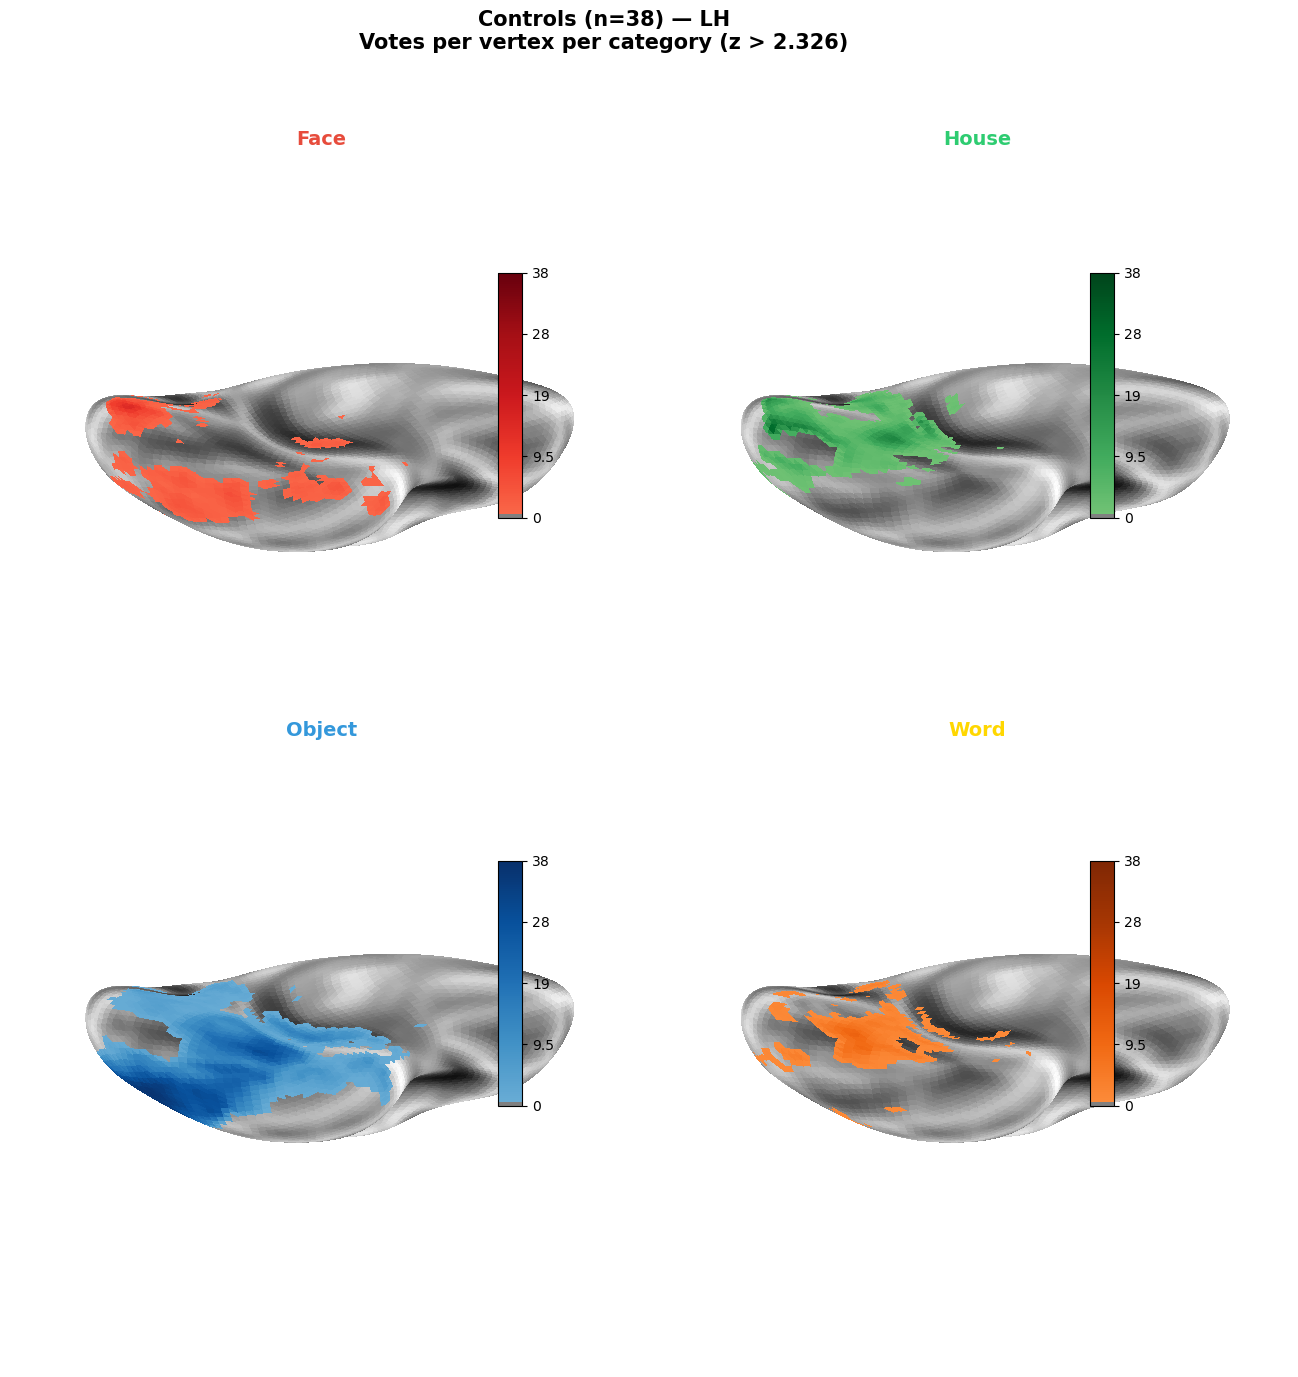

  Saved: /user_data/csimmon2/sym_pt/group_results/figures/brain_figure_liu/group_ctrl_lh_heatmap_liu.png

── RH vote heatmaps ──


/tmp/ipykernel_51486/2363348410.py:43: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.93])


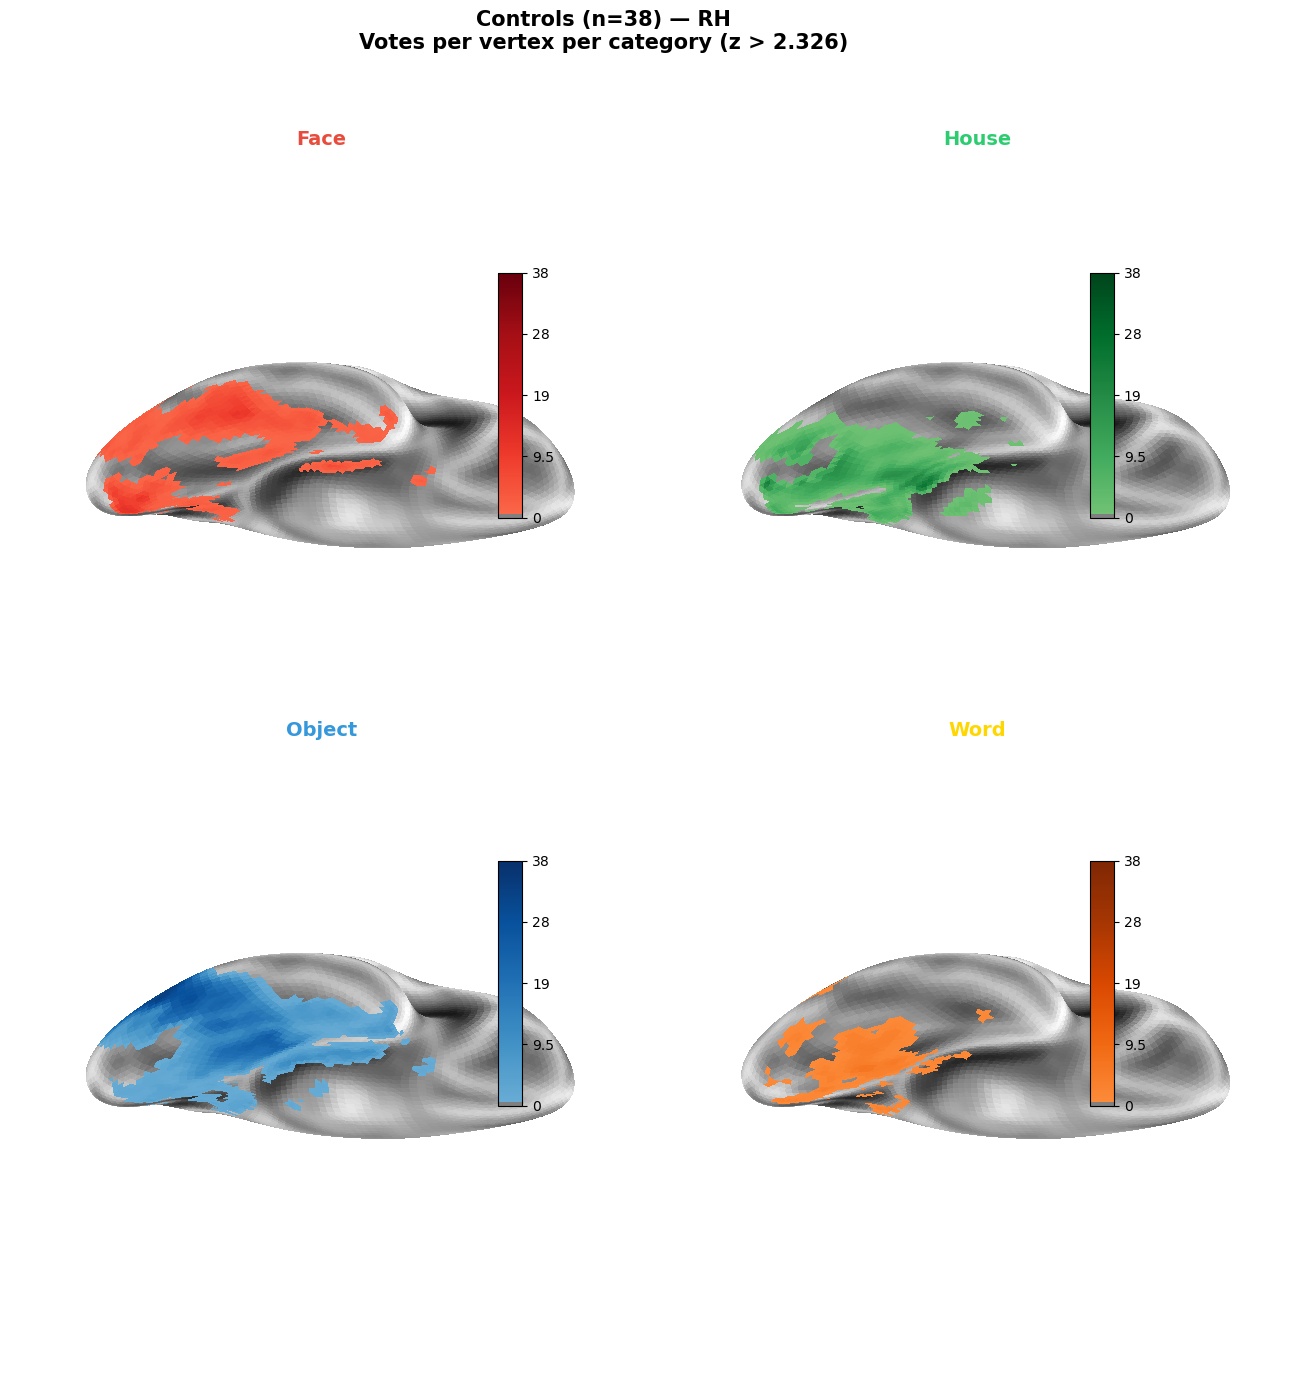

  Saved: /user_data/csimmon2/sym_pt/group_results/figures/brain_figure_liu/group_ctrl_rh_heatmap_liu.png


In [10]:
def accumulate_votes(hemi_nl):
    votes = np.zeros((N_VERTICES, 5), dtype=int)
    n_subs = 0
    for sid in ctrl_sids:
        info = subjects[sid]
        first_ses = info['sessions'][0]
        sz = project_zstats_to_surface(sid, first_ses, hemi_nl)
        if sz is None:
            continue
        labels = surface_wta(sz, GROUP_ZTHRESH)
        for v in range(N_VERTICES):
            if labels[v] > 0:
                votes[v, labels[v]] += 1
        n_subs += 1
    return votes, n_subs


CAT_CMAPS = {'face': 'Reds', 'house': 'Greens', 'object': 'Blues', 'word': 'Oranges'}

for hemi_nl, hemi_label in [('left', 'LH'), ('right', 'RH')]:
    print(f'\n── {hemi_label} vote heatmaps ──')
    votes, n_subs = accumulate_votes(hemi_nl)
    votc = votc_mask_surf_lh if hemi_nl == 'left' else votc_mask_surf_rh

    fig, axes = plt.subplots(2, 2, figsize=(14, 14),
                              subplot_kw={'projection': '3d'})
    for idx, cat in enumerate(CATEGORIES):
        ax = axes[idx // 2, idx % 2]
        cat_idx = idx + 1
        count_data = votes[:, cat_idx].astype(float)
        count_data[~votc] = 0
        plot_surf_stat_map(fsaverage[f'infl_{hemi_nl}'], count_data,
                           bg_map=fsaverage[f'sulc_{hemi_nl}'],
                           hemi=hemi_nl, view='ventral',
                           cmap=CAT_CMAPS[cat], threshold=1, vmax=n_subs,
                           colorbar=True, axes=ax)
        ax.set_title(cat.capitalize(), fontsize=14, fontweight='bold',
                     color=CAT_COLORS[cat])

    plt.suptitle(f'Controls (n={n_subs}) — {hemi_label}\n'
                 f'Votes per vertex per category (z > {GROUP_ZTHRESH})',
                 fontsize=15, fontweight='bold')
    plt.tight_layout(rect=[0, 0, 1, 0.93])
    out = os.path.join(OUT_DIR, f'group_ctrl_{hemi_label.lower()}_heatmap_liu.png')
    plt.savefig(out, dpi=300, bbox_inches='tight', transparent=True)
    plt.show()
    print(f'  Saved: {out}')